# 04. PyTorch Custom Dataset

This notebook builds an image classification workflow on the Fashion MNIST dataset using PyTorch and TorchVision — covering data loading, a baseline linear model, and a full training/evaluation loop.

- `torchvision.datasets` — provides ready-to-use vision datasets with built-in train/test splits
- `torch.utils.data.DataLoader` — batches and shuffles data for training
- `nn.Sequential` — chains layers into a simple feed-forward model

**Note:** This notebook trains on CPU by default; a CUDA/ROCm device is only used if detected in the setup cell.

**Resources**
1. Notebook: https://www.learnpytorch.io/04_pytorch_custom_datasets/
2. Video: https://www.youtube.com/watch?v=V_xro1bcAuA&t=5277s

## Setup & Environment Check

Import the core libraries and detect the available device up front so every tensor and model can be moved to the right place later in the notebook.

- `torch.cuda.is_available()` — checks for a CUDA/ROCm-capable GPU and falls back to CPU otherwise
- `warnings.filterwarnings("ignore")` — suppresses noisy library warnings so the output stays readable
- `DEVICE` — global variable set here and reused throughout the notebook for `.to(DEVICE)` calls

**Note:** This model is trained entirely on `"cpu"` later in the notebook — `DEVICE` is detected here for reference and timing comparisons, not used to move the model or data.

In [20]:
# Capture runtime details so later cells can choose the right device.
import platform
import torch
from torch import nn
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision  import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Keep notebook output focused on the example results.
warnings.filterwarnings("ignore")

print(f"--- System Information ---")
print(f"Platform: {platform.platform()}")
print(f"Python:   {platform.python_version()}")
print(f"PyTorch:  {torch.__version__}")

print(f"\n--- GPU/ROCm Accelerators ---")
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Device Count:   {torch.cuda.device_count()}")
    print(f"Primary Device: {torch.cuda.get_device_name(0)}")
    DEVICE = torch.device("cuda:0")
else:
    print("Optimization Note: No CUDA-capable GPU detected. Training and inference will use the CPU.")
    DEVICE = torch.device("cpu")


--- System Information ---
Platform: Windows-11-10.0.26200-SP0
Python:   3.12.13
PyTorch:  2.9.1+rocm7.2.1

--- GPU/ROCm Accelerators ---
CUDA Available: True
Device Count:   1
Primary Device: AMD Radeon RX 7900 XT


### Downloading a Dataset (Getting the Data)

Subset dataset (3 classes, 1000 images per class consisting of 750 training and 250 testing images)
- Source: "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

In [19]:
import requests
import zipfile
from pathlib import Path

# Download the dataset and extract it to a local directory
data_dir = Path("data")
images_dir = data_dir / "pizza_steak_sushi"

# Download the dataset if it doesn't already exist
if images_dir.exists():
    print(f"Dataset already exists at {images_dir}. Skipping download.")
else:
    print(f"Downloading dataset to {images_dir}...")
    url = "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"
    response = requests.get(url)
    with open(data_dir / "pizza_steak_sushi.zip", "wb") as f:
        f.write(response.content)
    with zipfile.ZipFile(data_dir / "pizza_steak_sushi.zip", "r") as zip_ref:
        zip_ref.extractall(images_dir)

Dataset already exists at data\pizza_steak_sushi. Skipping download.


### Data exploration

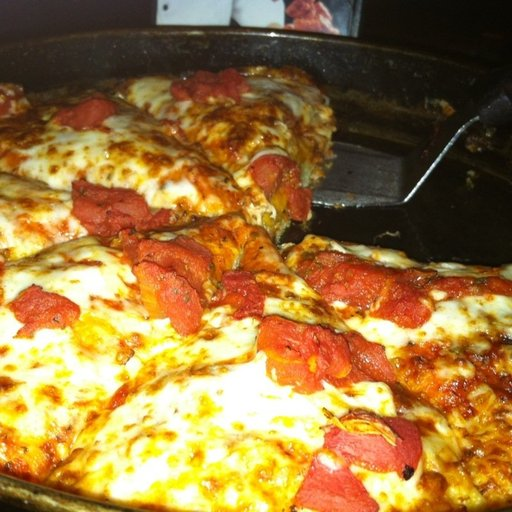

In [22]:
from IPython.display import display,HTML
from PIL import Image
# Display a sample image from the dataset
sample_image_path = "data/pizza_steak_sushi/train/pizza/1044789.jpg"

with Image.open(sample_image_path) as i:
    display(i)

In [26]:
import os
def walk_through_dir(dir_path, sample_size=5):
    """
    Walks through a directory and prints out its contents.
    """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"Found directory: {dirpath}")
        for file_name in filenames[:sample_size]:
            print(f"\t{file_name}")

walk_through_dir(images_dir, sample_size=10)

Found directory: data\pizza_steak_sushi
Found directory: data\pizza_steak_sushi\test
Found directory: data\pizza_steak_sushi\test\pizza
	1152100.jpg
	1503858.jpg
	1687143.jpg
	1925494.jpg
	194643.jpg
	195160.jpg
	2003290.jpg
	2019408.jpg
	2111981.jpg
	2124579.jpg
Found directory: data\pizza_steak_sushi\test\steak
	100274.jpg
	1016217.jpg
	1285886.jpg
	1302563.jpg
	1627703.jpg
	1868005.jpg
	1882831.jpg
	2117351.jpg
	2144308.jpg
	27415.jpg
Found directory: data\pizza_steak_sushi\test\sushi
	1172255.jpg
	1230335.jpg
	1245193.jpg
	1434806.jpg
	1600999.jpg
	1680893.jpg
	1742201.jpg
	175783.jpg
	1987407.jpg
	207578.jpg
Found directory: data\pizza_steak_sushi\train
Found directory: data\pizza_steak_sushi\train\pizza
	1008844.jpg
	1033251.jpg
	1044789.jpg
	1089334.jpg
	1105700.jpg
	12301.jpg
	1285298.jpg
	138855.jpg
	1412034.jpg
	1524655.jpg
Found directory: data\pizza_steak_sushi\train\steak
	100135.jpg
	1225762.jpg
	1257104.jpg
	1264154.jpg
	1382427.jpg
	1413972.jpg
	1598345.jpg
	1615395.jpg

In [27]:
# Setting train and test directories
train_dir = images_dir / "train"
test_dir = images_dir / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

### Turning images into tensors

## Video Timestamp

Reference point in the source tutorial video for this section of the notebook.

- `~20:13:59` — marks the "Becoming one with the Data" segment, useful for jumping back to the explanation if revisiting this notebook later